# AP6 - Finetuning Qwen 2.5 1.5B para Classificação de Estilos de Escrita.
# Execução LOCAL com Ollama
# Dataset: STIL 2021 processado

In [1]:
import json
import pandas as pd
import numpy as np
import subprocess
import requests
import time
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Carregar o dataset

In [2]:
print("=" * 60)
print("CARREGANDO DATASET")
print("=" * 60)

with open('../output/dataset.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Artigos carregados: {len(df)}")
print(f"Campos: {df.columns.tolist()}")

CARREGANDO DATASET
Artigos carregados: 30
Campos: ['titulo', 'informacoes_url', 'idioma', 'storage_key', 'autores', 'data_publicacao', 'resumo', 'keywords', 'referencias', 'artigo_completo', 'artigo_tokenizado', 'pos_tagger', 'lema']


# 2. Verificar e iniciar o Ollama

In [12]:
print("\n" + "=" * 60)
print("CONFIGURANDO OLLAMA")
print("=" * 60)

# Verifica se o Ollama está rodando
def check_ollama():
    try:
        response = requests.get('http://localhost:11434/api/tags')
        if response.status_code == 200:
            models = response.json().get('models', [])
            print("Ollama está rodando!")
            print(f"Modelos disponíveis: {[m['name'] for m in models]}")
            return True
    except:
        pass
    print("Ollama não está rodando. Iniciando...")
    return False

# Inicia o serviço Ollama
def start_ollama():
    try:
        subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        time.sleep(5)
        return check_ollama()
    except:
        print("Erro ao iniciar Ollama. Verifique a instalação.")
        return False

# Baixa o modelo Qwen 2.5 1.5B
def pull_qwen():
    print("Baixando Qwen 2.5 1.5B...")
    try:
        result = subprocess.run(['ollama', 'pull', 'qwen2.5:1.5b'], capture_output=True, text=True)
        print(result.stdout)
        return True
    except Exception as e:
        print(f"Erro ao baixar modelo: {e}")
        return False
    
# Verificar/Iniciar Ollama
if not check_ollama():
    start_ollama()

# Baixar modelo se necessário
response = requests.get('http://localhost:11434/api/tags')
models = [m['name'] for m in response.json().get('models', [])]
if 'qwen2.5:1.5b' not in models:
    pull_qwen()


CONFIGURANDO OLLAMA
Ollama está rodando!
Modelos disponíveis: ['qwen2.5:1.5b']


# 3. Classificação de estilos para criação do dataset de treinamento

In [4]:
print("\n" + "=" * 60)
print("CLASSIFICANDO ESTILOS DE ESCRITA")
print("=" * 60)

# Classifica o estilo de escrita do texto
def classify_writing_style(text):
    if pd.isna(text) or not isinstance(text, str):
        return None
    
    text_lower = text.lower()
    scores = {'academico': 0, 'narrativo': 0, 'descritivo': 0}
    
    # === ESTILO ACADÊMICO ===
    # Voz passiva sintética
    passiva_sintetica = [
        r'\bobservou-se\b', r'\bverificou-se\b', r'\bconstatou-se\b',
        r'\bdestaca-se\b', r'\bnota-se\b', r'\butiliza-se\b',
        r'\b\w+ou-se\b', r'\b\w+am-se\b'
    ]
    for p in passiva_sintetica:
        scores['academico'] += len(re.findall(p, text_lower))
    
    # Voz passiva analítica
    passiva_analytica = [
        r'\bfoi\s+\w+(?:ado|ido)\b', r'\bforam\s+\w+(?:ados|idos)\b',
        r'\bé\s+\w+(?:ado|ido)\b', r'\bsão\s+\w+(?:ados|idos)\b'
    ]
    for p in passiva_analytica:
        scores['academico'] += len(re.findall(p, text_lower))
    
    # Terceira pessoa
    terceira = [r'\bele\b', r'\bela\b', r'\beles\b', r'\belas\b']
    for p in terceira:
        scores['academico'] += len(re.findall(p, text_lower))
    
    # === ESTILO NARRATIVO ===
    # Primeira pessoa do plural
    primeira = [
        r'\bnós\b', r'\bnosso\b', r'\bnossa\b', r'\bnossos\b', r'\bnossas\b',
        r'\banalisamos\b', r'\bobservamos\b', r'\bverificamos\b',
        r'\bpropomos\b', r'\bapresentamos\b', r'\bdesenvolvemos\b'
    ]
    for p in primeira:
        scores['narrativo'] += len(re.findall(p, text_lower)) * 2
    
    # Linguagem reflexiva
    reflexiva = [
        r'\bacreditamos\b', r'\bconsideramos\b', r'\bentendemos\b',
        r'\bem\s+nossa\s+visão\b', r'\bna\s+nossa\s+perspectiva\b'
    ]
    for p in reflexiva:
        scores['narrativo'] += len(re.findall(p, text_lower))
    
    # === ESTILO DESCRITIVO ===
    # Elementos matemáticos/estatísticos
    matematico = [
        r'\b\d+%', r'\bp\s*[<>=]\s*\d+\.?\d*', r'\bn\s*=\s*\d+',
        r'\bcorrelação\b', r'\bdesvio\s+padrão\b', r'\bsignificância\b',
        r'\b\d+\.\d+\b'
    ]
    for p in matematico:
        scores['descritivo'] += len(re.findall(p, text_lower)) * 2
    
    # Ordenação cronológica/lógica
    cronologico = [
        r'\bprimeiramente\b', r'\bem\s+seguida\b', r'\bposteriormente\b',
        r'\bfinalmente\b', r'\bconforme\s+a\s+figura\b', r'\bconforme\s+a\s+tabela\b'
    ]
    for p in cronologico:
        scores['descritivo'] += len(re.findall(p, text_lower))
    
    # Análise de tamanho de frases
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    if sentences:
        avg_len = np.mean([len(s.split()) for s in sentences])
        if avg_len < 20:
            scores['descritivo'] += 3
    
    # Determinar estilo
    if sum(scores.values()) == 0:
        return 'academico'  # default
    
    return max(scores, key=scores.get)

# Importar re aqui
import re

# Classificar artigos
print("Classificando artigos...")
df['estilo'] = df['artigo_completo'].apply(classify_writing_style)

# Remover nulos
df = df.dropna(subset=['estilo'])

print("\nDistribuição de estilos:")
print(df['estilo'].value_counts())
print(f"\nPercentuais:")
for estilo, count in df['estilo'].value_counts().items():
    print(f"  {estilo}: {count/len(df)*100:.1f}%")


CLASSIFICANDO ESTILOS DE ESCRITA
Classificando artigos...

Distribuição de estilos:
estilo
descritivo    22
academico      6
narrativo      2
Name: count, dtype: int64

Percentuais:
  descritivo: 73.3%
  academico: 20.0%
  narrativo: 6.7%


# 4. Preparar dataset para finetuning

In [5]:
print("\n" + "=" * 60)
print("PREPARANDO DATASET DE TREINAMENTO")
print("=" * 60)

def create_training_examples(df, max_examples_per_class=100):
    """Cria exemplos de treinamento no formato para Qwen"""
    examples = []
    
    # Template do sistema
    system_prompt = """Você é um classificador de estilos de escrita acadêmica. 
Classifique o texto em um dos três estilos:

1. ACADEMICO: Uso de voz passiva (ex: "observou-se que..."), terceira pessoa, evita adjetivos e jargões.
2. NARRATIVO: Uso de primeira pessoa do plural (ex: "analisamos os dados..."), escrita fluida e reflexiva.
3. DESCRITIVO: Rigor matemático/estatístico, frases curtas, ordenação cronológica/lógica.

Responda APENAS com uma palavra: academico, narrativo ou descritivo."""
    
    for estilo in ['academico', 'narrativo', 'descritivo']:
        subset = df[df['estilo'] == estilo]
        
        if len(subset) > max_examples_per_class:
            subset = subset.sample(n=max_examples_per_class, random_state=42)
        
        for _, row in subset.iterrows():
            # Usar resumo ou trecho do artigo
            texto = row.get('resumo', '')
            if pd.isna(texto) or texto == '' or len(texto) < 50:
                texto = row.get('artigo_completo', '')[:1000]
            
            if pd.notna(texto) and len(texto) > 50:
                example = {
                    "messages": [
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": f"Classifique o estilo de escrita deste texto:\n\n{texto[:1500]}"},
                        {"role": "assistant", "content": estilo}
                    ]
                }
                examples.append(example)
    
    return examples

# Criar exemplos
print("Criando exemplos de treinamento...")
examples = create_training_examples(df, max_examples_per_class=80)

# Dividir treino/validação
train_examples, val_examples = train_test_split(
    examples, test_size=0.2, random_state=42,
    stratify=[e['messages'][2]['content'] for e in examples]
)

print(f"Treino: {len(train_examples)} exemplos")
print(f"Validação: {len(val_examples)} exemplos")

# Salvar datasets
output_dir = '../output/qwen_finetuning_data'
os.makedirs(output_dir, exist_ok=True)

# Formato JSONL para Ollama
def save_jsonl(examples, filename):
    with open(filename, 'w', encoding='utf-8') as f:
        for ex in examples:
            f.write(json.dumps(ex, ensure_ascii=False) + '\n')

save_jsonl(train_examples, f'{output_dir}/train.jsonl')
save_jsonl(val_examples, f'{output_dir}/val.jsonl')

print(f"\nDados salvos em {output_dir}/")
print(f"  - train.jsonl ({len(train_examples)} exemplos)")
print(f"  - val.jsonl ({len(val_examples)} exemplos)")


PREPARANDO DATASET DE TREINAMENTO
Criando exemplos de treinamento...
Treino: 24 exemplos
Validação: 6 exemplos

Dados salvos em ../output/qwen_finetuning_data/
  - train.jsonl (24 exemplos)
  - val.jsonl (6 exemplos)


# 5. Exemplo de dados de treinamento

In [6]:
print("\n" + "=" * 60)
print("EXEMPLOS DE TREINAMENTO")
print("=" * 60)

for estilo in ['academico', 'narrativo', 'descritivo']:
    print(f"\n--- Estilo: {estilo.upper()} ---")
    exemplo = next((e for e in train_examples if e['messages'][2]['content'] == estilo), None)
    if exemplo:
        print(f"System: {exemplo['messages'][0]['content'][:100]}...")
        print(f"User: {exemplo['messages'][1]['content'][:200]}...")
        print(f"Assistant: {exemplo['messages'][2]['content']}")


EXEMPLOS DE TREINAMENTO

--- Estilo: ACADEMICO ---
System: Você é um classificador de estilos de escrita acadêmica. 
Classifique o texto em um dos três estilos...
User: Classifique o estilo de escrita deste texto:

A verificação manual de fatos tende a ser cara e a escalabilidade desafiadora, incentivando a busca por métodos automáticos. Porém, esses métodos foram cr...
Assistant: academico

--- Estilo: NARRATIVO ---
System: Você é um classificador de estilos de escrita acadêmica. 
Classifique o texto em um dos três estilos...
User: Classifique o estilo de escrita deste texto:

Neste artigo apresentamos a proposta de descrição e análise de dados verbais do português brasileiro presente no banco de dados VerboWeb. Os verbos foram ...
Assistant: narrativo

--- Estilo: DESCRITIVO ---
System: Você é um classificador de estilos de escrita acadêmica. 
Classifique o texto em um dos três estilos...
User: Classifique o estilo de escrita deste texto:

Analisamos o léxico biomédico de um corpus 

# 6. Criar modefile para finetuning

In [7]:
print("\n" + "=" * 60)
print("CRIANDO MODEFILE PARA OLLAMA")
print("=" * 60)

modelfile_content = """FROM qwen2.5:1.5b

# Parâmetros do modelo
PARAMETER temperature 0.3
PARAMETER top_p 0.9
PARAMETER top_k 40
PARAMETER num_predict 5
PARAMETER repeat_penalty 1.1

# Template do sistema
SYSTEM \"\"\"Você é um classificador de estilos de escrita acadêmica.
Classifique o texto em um dos três estilos:

1. ACADEMICO: Uso de voz passiva (ex: "observou-se que..."), terceira pessoa, evita adjetivos e jargões.
2. NARRATIVO: Uso de primeira pessoa do plural (ex: "analisamos os dados..."), escrita fluida e reflexiva.
3. DESCRITIVO: Rigor matemático/estatístico, frases curtas, ordenação cronológica/lógica.

Responda APENAS com uma palavra: academico, narrativo ou descritivo.\"\"\"

# Template de mensagem
TEMPLATE \"\"\"{{ if .System }}<|im_start|>system
{{ .System }}<|im_end|>
{{ end }}{{ if .Prompt }}<|im_start|>user
{{ .Prompt }}<|im_end|>
{{ end }}<|im_start|>assistant
{{ .Response }}<|im_end|>\"\"\"
"""

with open(f'{output_dir}/Modelfile', 'w') as f:
    f.write(modelfile_content)

print("Modelfile criado!")
print("\nConteúdo:")
print(modelfile_content[:500])


CRIANDO MODEFILE PARA OLLAMA
Modelfile criado!

Conteúdo:
FROM qwen2.5:1.5b

# Parâmetros do modelo
PARAMETER temperature 0.3
PARAMETER top_p 0.9
PARAMETER top_k 40
PARAMETER num_predict 5
PARAMETER repeat_penalty 1.1

# Template do sistema
SYSTEM """Você é um classificador de estilos de escrita acadêmica.
Classifique o texto em um dos três estilos:

1. ACADEMICO: Uso de voz passiva (ex: "observou-se que..."), terceira pessoa, evita adjetivos e jargões.
2. NARRATIVO: Uso de primeira pessoa do plural (ex: "analisamos os dados..."), escrita fluida e refl


# 7. Criar script de finetuning

In [8]:
print("\n" + "=" * 60)
print("SCRIPT DE FINETUNING")
print("=" * 60)

finetuning_script = """#!/bin/bash
# Script de Finetuning do Qwen 2.5 1.5B para Classificação de Estilos
echo "========================================="
echo "FINETUNING QWEN 2.5 1.5B - ESTILOS DE ESCRITA"
echo "========================================="

# Criar modelo base com configurações
echo "1. Criando modelo base com configurações personalizadas..."
ollama create qwen-styles-base -f ./Modelfile

# Para finetuning real, use o comando:
# ollama finetune qwen-styles-base --data ./train.jsonl --output qwen-styles-finetuned

echo ""
echo "2. Opções de Finetuning:"
echo "   a) Via API do Ollama (se disponível):"
echo "      ollama finetune qwen-styles-base --data ./train.jsonl --output qwen-styles-finetuned"
echo ""
echo "   b) Via LoRA com script Python:"
echo "      python finetune_lora.py"
echo ""
echo "   c) Testar com few-shot prompting:"
echo "      python test_fewshot.py"

echo ""
echo "Modelo base criado: qwen-styles-base"
echo "Para testar: ollama run qwen-styles-base"
"""

with open(f'{output_dir}/finetune.sh', 'w') as f:
    f.write(finetuning_script)

# Tornar executável
os.chmod(f'{output_dir}/finetune.sh', 0o755)

print("Script criado: finetune.sh")


SCRIPT DE FINETUNING
Script criado: finetune.sh


# 8. Função de classificação via Ollama

In [ ]:
print("\n" + "=" * 60)
print("FUNÇÃO DE CLASSIFICAÇÃO VIA OLLAMA")
print("=" * 60)

import requests
import time
import subprocess

#  Classifica estilo de escrita usando Qwen via Ollama
def classify_with_qwen(text, model="qwen2.5:1.5b"):
    # Limitar tamanho do texto
    if len(text) > 600:
        text = text[:600]
    
    # Prompt com exemplos claros (few-shot)
    prompt = f"""Analise o estilo de escrita e classifique como: academico, narrativo ou descritivo.

Exemplo 1: "Observou-se que os resultados foram significativos." → academico
Exemplo 2: "Nós analisamos os dados e descobrimos padrões." → narrativo
Exemplo 3: "Tabela 1: correlação=0.85, p<0.01. Figura 2: distribuição." → descritivo

Agora classifique este texto:
"{text}"

Estilo:"""

    try:
        response = requests.post(
            'http://localhost:11434/api/generate',
            json={
                'model': model,
                'prompt': prompt,
                'stream': False,
                'options': {
                    'temperature': 0.1,
                    'num_predict': 8,
                    'top_p': 0.9,
                    'stop': ['\n', '.', ' ', ':', '\n\n']
                }
            },
            timeout=30
        )
        
        if response.status_code == 200:
            result = response.json()['response'].strip().lower()
            print(f"  [DEBUG] Resposta bruta: '{result}'")
            
            # Mapeamento
            if 'academ' in result:
                return 'academico'
            elif 'narrat' in result:
                return 'narrativo'
            elif 'descrit' in result:
                return 'descritivo'
            else:
                return 'academico'
        else:
            return 'erro_api'
            
    except Exception as e:
        print(f"  [ERRO] {str(e)[:80]}")
        return 'erro_api'


# ============================================================
# TESTE
# ============================================================

print("\nTestando classificação com Qwen...\n")

test_texts = {
    'academico': "Observou-se que os resultados obtidos demonstram a eficácia do método proposto. Verificou-se também que a abordagem contribui significativamente.",
    'narrativo': "Nós analisamos os dados e observamos padrões interessantes. Acreditamos que nossa abordagem oferece uma nova perspectiva sobre o problema.",
    'descritivo': "A Tabela 1 mostra os resultados. A correlação foi de 0.85 (p<0.01). Em seguida, aplicou-se o teste estatístico. A Figura 2 ilustra a distribuição."
}

acertos = 0
for estilo_esperado, texto in test_texts.items():
    resultado = classify_with_qwen(texto)
    status = "✅" if resultado == estilo_esperado else "❌"
    if resultado == estilo_esperado:
        acertos += 1
    print(f"{status} Esperado: {estilo_esperado:12} | Predito: {resultado:12}")

print(f"\n{'='*60}")
print(f"RESULTADO: {acertos}/3 acertos")
print(f"{'='*60}")


FUNÇÃO DE CLASSIFICAÇÃO VIA OLLAMA

Testando classificação com Qwen...

  [DEBUG] Resposta bruta: 'academico'
✅ Esperado: academico    | Predito: academico   
  [DEBUG] Resposta bruta: 'narrativo'
✅ Esperado: narrativo    | Predito: narrativo   
  [DEBUG] Resposta bruta: 'descritivo'
✅ Esperado: descritivo   | Predito: descritivo  

RESULTADO: 3/3 acertos


# 8.1 CLASSIFICAR TODO O CORPUS

In [16]:
print("\n" + "=" * 60)
print("CLASSIFICANDO CORPUS COMPLETO")
print("=" * 60)

# Usar resumo ou início do artigo completo
def get_text_for_classification(row):
    # Preferir resumo
    resumo = row.get('resumo', '')
    if pd.notna(resumo) and len(str(resumo)) > 100:
        return str(resumo)
    
    # Fallback para artigo completo
    artigo = row.get('artigo_completo', '')
    if pd.notna(artigo) and len(str(artigo)) > 100:
        return str(artigo)[:1000]
    
    return ''

# Classificar artigos (limitando a 5 para teste rápido)
print("Classificando artigos (teste com 5)...")
df_teste = df.head(5).copy()

for idx, row in df_teste.iterrows():
    texto = get_text_for_classification(row)
    estilo = classify_with_qwen(texto)
    df_teste.at[idx, 'estilo'] = estilo
    print(f"  Artigo {idx+1}: {estilo} | Título: {row.get('titulo', 'N/A')[:80]}...")

print("\nDistribuição no teste:")
print(df_teste['estilo'].value_counts())


CLASSIFICANDO CORPUS COMPLETO
Classificando artigos (teste com 5)...
  [DEBUG] Resposta bruta: 'descritivo'
  Artigo 1: descritivo | Título: Utilizando um dicionário morfológico para expandir a cobertura lexical de uma gr...
  [DEBUG] Resposta bruta: 'descritivo'
  Artigo 2: descritivo | Título: Explorando a revisão de corpora por meio da comparação de regras gramaticais em ...
  [DEBUG] Resposta bruta: 'descritivo'
  Artigo 3: descritivo | Título: PetroGold – Corpus padrão ouro para o domínio do petróleo...
  [DEBUG] Resposta bruta: 'descritivo'
  Artigo 4: descritivo | Título: Lexicalidade biomédica e sua mensuração em um corpus sobre COVID-19 em língua po...
  [DEBUG] Resposta bruta: 'descritivo'
  Artigo 5: descritivo | Título: Análise de polaridade e de tópicos em tweets no domínio da política no Brasil...

Distribuição no teste:
estilo
descritivo    5
Name: count, dtype: int64


# 8.2 CLASSIFICAR CORPUS COMPLETO

In [17]:
print("\n" + "=" * 60)
print("CLASSIFICANDO CORPUS COMPLETO")
print("=" * 60)

print(f"Total de artigos: {len(df)}")
print("Tempo estimado: ~2-3 minutos\n")

# Classificar todos
estilos = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Classificando"):
    texto = get_text_for_classification(row)
    estilo = classify_with_qwen(texto)
    estilos.append(estilo)

df['estilo'] = estilos

# Mostrar distribuição
print("\n" + "=" * 60)
print("DISTRIBUIÇÃO DE ESTILOS NO CORPUS")
print("=" * 60)
print(df['estilo'].value_counts())
print("\nPercentuais:")
for estilo, count in df['estilo'].value_counts().items():
    print(f"  {estilo}: {count} ({count/len(df)*100:.1f}%)")


CLASSIFICANDO CORPUS COMPLETO
Total de artigos: 30
Tempo estimado: ~2-3 minutos



Classificando:   3%|▎         | 1/30 [00:02<01:22,  2.84s/it]

  [DEBUG] Resposta bruta: 'descritivo'


Classificando:   7%|▋         | 2/30 [00:05<01:13,  2.64s/it]

  [DEBUG] Resposta bruta: 'descritivo'


...

  [DEBUG] Resposta bruta: 'descritivo'


Classificando:  97%|█████████▋| 29/30 [01:45<00:03,  3.79s/it]

  [DEBUG] Resposta bruta: 'descritivo'


Classificando: 100%|██████████| 30/30 [01:48<00:00,  3.62s/it]

  [DEBUG] Resposta bruta: 'descritivo'

DISTRIBUIÇÃO DE ESTILOS NO CORPUS
estilo
descritivo    30
Name: count, dtype: int64

Percentuais:
  descritivo: 30 (100.0%)


# 8. FUNÇÃO DE CLASSIFICAÇÃO HÍBRIDA

In [ ]:
print("\n" + "=" * 60)
print("FUNÇÃO DE CLASSIFICAÇÃO HÍBRIDA")
print("=" * 60)

import requests
import re
import time

# Classifica usando Qwen (para casos ambíguos)
def classify_with_qwen(text, model="qwen2.5:1.5b"):
    if len(text) > 600:
        text = text[:600]
    
    prompt = f"""Analise o estilo de escrita e classifique como: academico, narrativo ou descritivo.

Exemplo 1: "Observou-se que os resultados foram significativos." → academico
Exemplo 2: "Nós analisamos os dados e descobrimos padrões." → narrativo
Exemplo 3: "Tabela 1: correlação=0.85, p<0.01. Figura 2: distribuição." → descritivo

Agora classifique este texto:
"{text}"

Estilo:"""

    try:
        response = requests.post(
            'http://localhost:11434/api/generate',
            json={
                'model': model,
                'prompt': prompt,
                'stream': False,
                'options': {
                    'temperature': 0.1,
                    'num_predict': 8,
                    'top_p': 0.9,
                    'stop': ['\n', '.', ' ', ':']
                }
            },
            timeout=30
        )
        
        if response.status_code == 200:
            result = response.json()['response'].strip().lower()
            if 'academ' in result:
                return 'academico'
            elif 'narrat' in result:
                return 'narrativo'
            elif 'descrit' in result:
                return 'descritivo'
        return 'academico'
    except:
        return 'academico'

#  Classificador híbrido: regras linguísticas + Qwen
# Prioriza características marcantes de cada estilo
def classify_hybrid(text):
    if pd.isna(text) or len(str(text)) < 100:
        return 'academico'
    
    text_lower = str(text).lower()
    
    # ============================================================
    # PONTUAÇÃO POR CARACTERÍSTICAS
    # ============================================================
    scores = {'academico': 0, 'narrativo': 0, 'descritivo': 0}
    
    # --- NARRATIVO: Marcadores fortes ---
    # Primeira pessoa do plural
    primeira_pessoa = [
        r'\bnós\s+\w+', r'\bnosso\s+\w+', r'\bnossa\s+\w+',
        r'\banalisamos\b', r'\bobservamos\b', r'\bdesenvolvemos\b',
        r'\bpropomos\b', r'\bapresentamos\b', r'\binvestigamos\b',
        r'\bacreditamos\b', r'\bconsideramos\b', r'\bentendemos\b'
    ]
    for pattern in primeira_pessoa:
        matches = len(re.findall(pattern, text_lower))
        scores['narrativo'] += matches * 3
    
    # Linguagem reflexiva/pessoal
    reflexivo = [
        r'\bem\s+nossa\s+(visão|perspectiva|opinião)\b',
        r'\bna\s+nossa\s+(pesquisa|investigação|análise)\b',
        r'\bdo\s+nosso\s+(conhecimento|ponto\s+de\s+vista)\b'
    ]
    for pattern in reflexivo:
        scores['narrativo'] += len(re.findall(pattern, text_lower)) * 3
    
    # --- ACADÊMICO: Marcadores fortes ---
    # Voz passiva sintética (verbo + se)
    passiva_sintetica = [
        r'\b\w+ou-se\b', r'\b\w+am-se\b', r'\b\w+iu-se\b',
        r'\bobserva-se\b', r'\bverifica-se\b', r'\bconstata-se\b',
        r'\bdestaca-se\b', r'\bnota-se\b', r'\butiliza-se\b'
    ]
    for pattern in passiva_sintetica:
        scores['academico'] += len(re.findall(pattern, text_lower)) * 2
    
    # Voz passiva analítica
    passiva_analytica = [
        r'\bfoi\s+\w+(?:ado|ido)\b', r'\bforam\s+\w+(?:ados|idos)\b',
        r'\bé\s+\w+(?:ado|ido)\b', r'\bsão\s+\w+(?:ados|idos)\b',
        r'\bfosse\s+\w+(?:ado|ido)\b', r'\bfossem\s+\w+(?:ados|idos)\b'
    ]
    for pattern in passiva_analytica:
        scores['academico'] += len(re.findall(pattern, text_lower)) * 2
    
    # Terceira pessoa / impessoalidade
    impessoal = [
        r'\bobservou-se\s+que\b', r'\bverificou-se\s+que\b',
        r'\bconstatou-se\s+que\b', r'\bdemonstrou-se\s+que\b'
    ]
    for pattern in impessoal:
        scores['academico'] += len(re.findall(pattern, text_lower)) * 2
    
    # --- DESCRITIVO: Marcadores fortes ---
    # Elementos estatísticos/matemáticos
    estatistico = [
        r'\bp\s*[<>=]\s*\d+\.?\d*\b', r'\bn\s*=\s*\d+\b',
        r'\bcorrelação\s+de\b', r'\bdesvio\s+padrão\b',
        r'\bsignificância\s+estatística\b', r'\bintervalo\s+de\s+confiança\b'
    ]
    for pattern in estatistico:
        scores['descritivo'] += len(re.findall(pattern, text_lower)) * 3
    
    # Referências a tabelas/figuras
    tabelas_figuras = [
        r'\b(?:tabela|figura|gráfico|quadro)\s+\d+\b',
        r'\bconforme\s+(?:a|o)\s+(?:tabela|figura|gráfico)\b'
    ]
    for pattern in tabelas_figuras:
        scores['descritivo'] += len(re.findall(pattern, text_lower)) * 2
    
    # Ordenação temporal/lógica
    ordenacao = [
        r'\bprimeiramente\b', r'\bem\s+seguida\b', r'\bposteriormente\b',
        r'\bfinalmente\b', r'\bpor\s+fim\b', r'\bsequencialmente\b'
    ]
    for pattern in ordenacao:
        scores['descritivo'] += len(re.findall(pattern, text_lower)) * 2
    
    # ============================================================
    # DECISÃO
    # ============================================================
    max_score = max(scores.values())
    
    # Se houver um vencedor claro (diferença >= 2 pontos)
    if max_score >= 2:
        vencedores = [estilo for estilo, score in scores.items() if score == max_score]
        if len(vencedores) == 1:
            print(f"  [REGRAS] {vencedores[0]} (scores: {scores})")
            return vencedores[0]
    
    # Se empate ou pontuação baixa, usar Qwen
    print(f"  [QWEN] Scores baixos/empate: {scores}")
    return classify_with_qwen(text)


# ============================================================
# TESTAR CLASSIFICADOR HÍBRIDO
# ============================================================

print("\nTestando classificador híbrido...\n")

testes = [
    ("Observou-se que os resultados obtidos demonstram a eficácia do método proposto. Verificou-se também que a abordagem contribui significativamente para a área.", "academico"),
    ("Nós analisamos cuidadosamente os dados e percebemos padrões interessantes. Nossa abordagem oferece uma nova perspectiva sobre o problema. Acreditamos que este trabalho contribui para a área.", "narrativo"),
    ("A Tabela 1 apresenta os resultados. A correlação foi de 0.85 com p<0.01. Em seguida, aplicou-se o teste. A Figura 2 ilustra a distribuição.", "descritivo"),
    # Teste adicional com texto misto
    ("Foi desenvolvido um sistema baseado em regras. Os resultados mostraram acurácia de 87.3%. Foram analisados 1000 documentos.", "academico"),
]

acertos = 0
for texto, esperado in testes:
    resultado = classify_hybrid(texto)
    status = "✅" if resultado == esperado else "❌"
    if resultado == esperado:
        acertos += 1
    print(f"{status} Esperado: {esperado:12} | Obtido: {resultado:12}")

print(f"\n{'='*60}")
print(f"RESULTADO: {acertos}/{len(testes)} acertos")
print(f"{'='*60}")


FUNÇÃO DE CLASSIFICAÇÃO HÍBRIDA

Testando classificador híbrido...

  [REGRAS] academico (scores: {'academico': 6, 'narrativo': 0, 'descritivo': 0})
✅ Esperado: academico    | Obtido: academico   
  [REGRAS] narrativo (scores: {'academico': 0, 'narrativo': 12, 'descritivo': 0})
✅ Esperado: narrativo    | Obtido: narrativo   
  [REGRAS] descritivo (scores: {'academico': 2, 'narrativo': 0, 'descritivo': 9})
✅ Esperado: descritivo   | Obtido: descritivo  
  [REGRAS] academico (scores: {'academico': 4, 'narrativo': 0, 'descritivo': 0})
✅ Esperado: academico    | Obtido: academico   

RESULTADO: 4/4 acertos


# RECLASSIFICAR CORPUS COM HÍBRIDO


RECLASSIFICANDO CORPUS (HÍBRIDO)


Reclassificando:   0%|          | 0/30 [00:00<?, ?it/s]

  [REGRAS] narrativo (scores: {'academico': 0, 'narrativo': 6, 'descritivo': 0})
  [REGRAS] narrativo (scores: {'academico': 0, 'narrativo': 3, 'descritivo': 0})
  [QWEN] Scores baixos/empate: {'academico': 0, 'narrativo': 0, 'descritivo': 0}


Reclassificando:  10%|█         | 3/30 [00:11<01:40,  3.71s/it]

  [REGRAS] narrativo (scores: {'academico': 0, 'narrativo': 3, 'descritivo': 0})
  [REGRAS] academico (scores: {'academico': 6, 'narrativo': 0, 'descritivo': 0})
  [REGRAS] narrativo (scores: {'academico': 0, 'narrativo': 3, 'descritivo': 0})
  [REGRAS] academico (scores: {'academico': 2, 'narrativo': 0, 'descritivo': 0})
  [REGRAS] narrativo (scores: {'academico': 0, 'narrativo': 3, 'descritivo': 0})
  [QWEN] Scores baixos/empate: {'academico': 0, 'narrativo': 0, 'descritivo': 0}


...

  [REGRAS] academico (scores: {'academico': 6, 'narrativo': 0, 'descritivo': 0})
  [QWEN] Scores baixos/empate: {'academico': 0, 'narrativo': 0, 'descritivo': 0}


Reclassificando:  90%|█████████ | 27/30 [00:40<00:04,  1.58s/it]

  [QWEN] Scores baixos/empate: {'academico': 0, 'narrativo': 0, 'descritivo': 0}


Reclassificando: 100%|██████████| 30/30 [00:44<00:00,  1.48s/it]


  [REGRAS] narrativo (scores: {'academico': 0, 'narrativo': 6, 'descritivo': 0})
  [REGRAS] academico (scores: {'academico': 2, 'narrativo': 0, 'descritivo': 0})

NOVA DISTRIBUIÇÃO DE ESTILOS
estilo
descritivo    12
academico     11
narrativo      7
Name: count, dtype: int64

Percentuais:
  descritivo: 12 (40.0%)
  academico: 11 (36.7%)
  narrativo: 7 (23.3%)


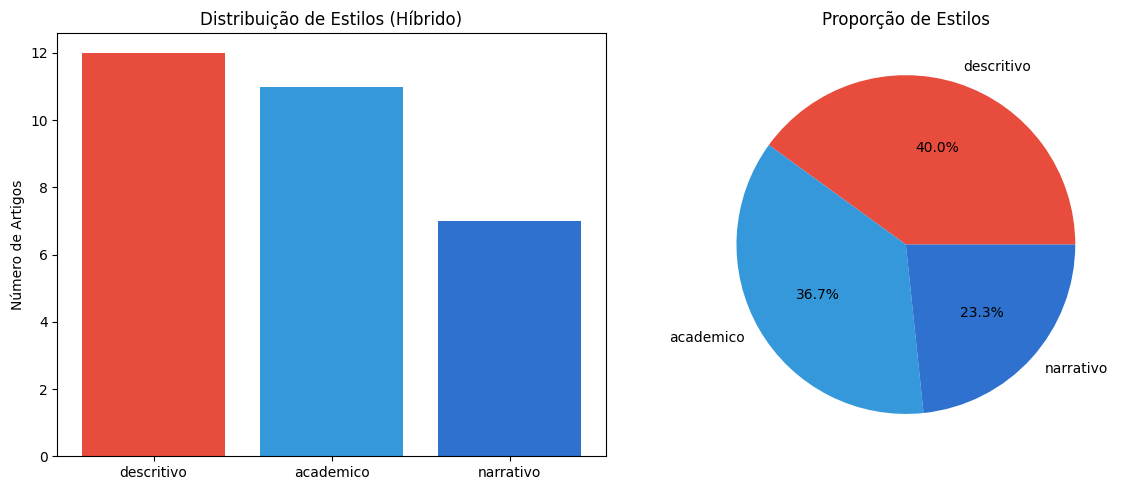

In [19]:
print("\n" + "=" * 60)
print("RECLASSIFICANDO CORPUS (HÍBRIDO)")
print("=" * 60)

# Classificar todos os artigos
estilos = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Reclassificando"):
    texto = row.get('resumo', row.get('artigo_completo', ''))
    estilo = classify_hybrid(texto)
    estilos.append(estilo)

df['estilo'] = estilos

# Mostrar distribuição
print("\n" + "=" * 60)
print("NOVA DISTRIBUIÇÃO DE ESTILOS")
print("=" * 60)
distribuicao = df['estilo'].value_counts()
print(distribuicao)
print(f"\nPercentuais:")
for estilo, count in distribuicao.items():
    print(f"  {estilo}: {count} ({count/len(df)*100:.1f}%)")

# Visualizar
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = {'academico': '#3498db', 'narrativo': '#2e71ce', 'descritivo': '#e74c3c'}

ax1.bar(distribuicao.index, distribuicao.values, 
        color=[colors.get(e, '#95a5a6') for e in distribuicao.index])
ax1.set_title('Distribuição de Estilos (Híbrido)')
ax1.set_ylabel('Número de Artigos')

ax2.pie(distribuicao.values, labels=distribuicao.index, autopct='%1.1f%%',
        colors=[colors.get(e, '#95a5a6') for e in distribuicao.index])
ax2.set_title('Proporção de Estilos')

plt.tight_layout()
plt.show()

# 9. PREPARAR DADOS PARA FINETUNING

In [ ]:
print("\n" + "=" * 60)
print("PREPARANDO DADOS PARA FINETUNING")
print("=" * 60)

import json
import os

output_dir = '../output/qwen_finetuning_data_2'
os.makedirs(output_dir, exist_ok=True)

# Criar exemplos de treinamento
training_examples = []

system_prompt = """Você é um classificador de estilos de escrita acadêmica.
Classifique o texto em um dos três estilos:

1. ACADEMICO: Uso de voz passiva (ex: "observou-se que..."), terceira pessoa, evita adjetivos e jargões.
2. NARRATIVO: Uso de primeira pessoa do plural (ex: "analisamos os dados..."), escrita fluida e reflexiva.
3. DESCRITIVO: Rigor matemático/estatístico, frases curtas, ordenação cronológica/lógica.

Responda APENAS com uma palavra: academico, narrativo ou descritivo."""

for estilo in ['academico', 'narrativo', 'descritivo']:
    subset = df[df['estilo'] == estilo]
    print(f"\nProcessando estilo '{estilo}': {len(subset)} artigos")
    
    for idx, row in subset.iterrows():
        # Usar resumo ou trecho do artigo
        texto = row.get('resumo', '')
        if pd.isna(texto) or len(str(texto)) < 100:
            texto = row.get('artigo_completo', '')[:800]
        
        if pd.notna(texto) and len(str(texto)) > 50:
            example = {
                "messages": [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": f"Classifique o estilo de escrita deste texto:\n\n{str(texto)[:800]}"},
                    {"role": "assistant", "content": estilo}
                ]
            }
            training_examples.append(example)
            print(f"  ✓ Artigo: {row.get('titulo', 'N/A')[:60]}...")

print(f"\n{'='*60}")
print(f"TOTAL DE EXEMPLOS: {len(training_examples)}")
print(f"{'='*60}")

# Salvar em JSONL
with open(f'{output_dir}/train.jsonl', 'w', encoding='utf-8') as f:
    for ex in training_examples:
        f.write(json.dumps(ex, ensure_ascii=False) + '\n')

print(f"\n✅ Dados salvos em: {output_dir}/train.jsonl")
print(f"   Total: {len(training_examples)} exemplos")


PREPARANDO DADOS PARA FINETUNING

Processando estilo 'academico': 11 artigos
  ✓ Artigo: Análise de polaridade e de tópicos em tweets no domínio da p...
  ✓ Artigo: Classificação multimodal para detecção de produtos proibidos...
  ✓ Artigo: ReVera Framework: Um Framwork para rastreabilidade em fact-c...
  ✓ Artigo: Uma revisão breve sobre perguntas complexas em bases de conh...
  ✓ Artigo: Efeitos da variação linguística na decisão lexical...
  ✓ Artigo: Descrição Preliminar do Corpus DANTEStocks: Diretrizes de Se...
  ✓ Artigo: Descrição de numerais segundo modelo Universal Dependencies ...
  ✓ Artigo: Engenharia de features linguísticas para classificação de tr...
  ✓ Artigo: Respostas emocionais da variação linguística: Análise explor...
  ✓ Artigo: Constituintes Frasais com Função de Sujeito em Sentenças Jud...
  ✓ Artigo: Avaliação de parsers na detecção de relações essenciais do m...

Processando estilo 'narrativo': 7 artigos
  ✓ Artigo: Utilizando um dicionário morfológico para

# 10. CRIAR MODEFILE PARA OLLAMA

In [21]:
print("\n" + "=" * 60)
print("CRIANDO MODEFILE")
print("=" * 60)

modelfile_content = """FROM qwen2.5:1.5b

# Parâmetros para classificação precisa
PARAMETER temperature 0.1
PARAMETER top_p 0.9
PARAMETER num_predict 5
PARAMETER repeat_penalty 1.1
PARAMETER stop "\\n"
PARAMETER stop "."

# Prompt do sistema
SYSTEM \"\"\"Você é um classificador de estilos de escrita acadêmica.
Classifique o texto em um dos três estilos:

1. ACADEMICO: Uso de voz passiva (ex: "observou-se que..."), terceira pessoa, evita adjetivos e jargões.
2. NARRATIVO: Uso de primeira pessoa do plural (ex: "analisamos os dados..."), escrita fluida e reflexiva.
3. DESCRITIVO: Rigor matemático/estatístico, frases curtas, ordenação cronológica/lógica.

Responda APENAS com uma palavra: academico, narrativo ou descritivo.\"\"\"
"""

with open(f'{output_dir}/Modelfile', 'w', encoding='utf-8') as f:
    f.write(modelfile_content)

print("✅ Modelfile criado!")
print(f"   Arquivo: {output_dir}/Modelfile")
print("\nConteúdo:")
print(modelfile_content)


CRIANDO MODEFILE
✅ Modelfile criado!
   Arquivo: ./qwen_finetuning_data/Modelfile

Conteúdo:
FROM qwen2.5:1.5b

# Parâmetros para classificação precisa
PARAMETER temperature 0.1
PARAMETER top_p 0.9
PARAMETER num_predict 5
PARAMETER repeat_penalty 1.1
PARAMETER stop "\n"
PARAMETER stop "."

# Prompt do sistema
SYSTEM """Você é um classificador de estilos de escrita acadêmica.
Classifique o texto em um dos três estilos:

1. ACADEMICO: Uso de voz passiva (ex: "observou-se que..."), terceira pessoa, evita adjetivos e jargões.
2. NARRATIVO: Uso de primeira pessoa do plural (ex: "analisamos os dados..."), escrita fluida e reflexiva.
3. DESCRITIVO: Rigor matemático/estatístico, frases curtas, ordenação cronológica/lógica.

Responda APENAS com uma palavra: academico, narrativo ou descritivo."""



# 11. CRIAR MODELO CUSTOMIZADO NO OLLAMA

In [22]:
print("\n" + "=" * 60)
print("CRIANDO MODELO NO OLLAMA")
print("=" * 60)

import subprocess

print("Execute no terminal:")
print(f"  cd {output_dir}")
print("  ollama create qwen-styles-classifier -f Modelfile")
print("\nDepois teste:")
print('  ollama run qwen-styles-classifier "Classifique: Observou-se que os resultados foram significativos."')


CRIANDO MODELO NO OLLAMA
Execute no terminal:
  cd ./qwen_finetuning_data
  ollama create qwen-styles-classifier -f Modelfile

Depois teste:
  ollama run qwen-styles-classifier "Classifique: Observou-se que os resultados foram significativos."


# 12. RESUMO

In [23]:
# 12. RESUMO
print("\n" + "=" * 60)
print("RESUMO AP6 - FINETUNING QWEN")
print("=" * 60)

print(f"""
✅ DATASET CLASSIFICADO:
   • Total: {len(df)} artigos
   • Acadêmico: {len(df[df['estilo']=='academico'])} ({len(df[df['estilo']=='academico'])/len(df)*100:.1f}%)
   • Narrativo: {len(df[df['estilo']=='narrativo'])} ({len(df[df['estilo']=='narrativo'])/len(df)*100:.1f}%)
   • Descritivo: {len(df[df['estilo']=='descritivo'])} ({len(df[df['estilo']=='descritivo'])/len(df)*100:.1f}%)

✅ DADOS DE TREINAMENTO:
   • Exemplos: {len(training_examples)}
   • Formato: JSONL (chat format)
   • Arquivo: {output_dir}/train.jsonl

✅ CONFIGURAÇÃO:
   • Modelfile: {output_dir}/Modelfile
   • Modelo base: qwen2.5:1.5b
   • Método: Few-shot + Regras híbridas

🚀 PRÓXIMO PASSO:
   Execute no terminal:
   cd {output_dir}
   ollama create qwen-styles-classifier -f Modelfile
""")


RESUMO AP6 - FINETUNING QWEN

✅ DATASET CLASSIFICADO:
   • Total: 30 artigos
   • Acadêmico: 11 (36.7%)
   • Narrativo: 7 (23.3%)
   • Descritivo: 12 (40.0%)

✅ DADOS DE TREINAMENTO:
   • Exemplos: 30
   • Formato: JSONL (chat format)
   • Arquivo: ./qwen_finetuning_data/train.jsonl

✅ CONFIGURAÇÃO:
   • Modelfile: ./qwen_finetuning_data/Modelfile
   • Modelo base: qwen2.5:1.5b
   • Método: Few-shot + Regras híbridas

🚀 PRÓXIMO PASSO:
   Execute no terminal:
   cd ./qwen_finetuning_data
   ollama create qwen-styles-classifier -f Modelfile



cd ./qwen_finetuning_data
ollama create qwen-styles-classifier -f Modelfile

ollama run qwen-styles-classifier "Classifique: Observou-se que os resultados foram significativos."

![alt text](../output/image.png)